In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import glob

scale = 2.5

SMALL_SIZE = 8*scale
MEDIUM_SIZE = 10*scale
BIGGER_SIZE = 12*scale
FIG_SIZE = (8,8)
LW = 4

rewards_list = []

def calc_ref() -> float:
    files = glob.glob("demos/full_se3/*.json")
    rewards_list = []

    for file in files:
        with open(file, "r") as f:
            data = json.load(f)

        rewards = data["rewards"]
        rewards_list.append(np.max(rewards))  # best reward in this demo

    return float(np.max(rewards_list))  # best reward across all demos

# SUBSAMPLE_REWARD_REF = -0.04110050667077303
# ABSOLUTE_REWARD_REF = -2.09511617436032
ABSOLUTE_REWARD_REF = calc_ref()

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


# Gaussian testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

min_log_std = -20
# min_log_std = -20
max_log_std = 2

# convert to std
min_std = np.exp(min_log_std)
max_std = np.exp(max_log_std)

# choose log-std samples across the range
log_stds = np.linspace(min_log_std, max_log_std, 60)
stds = np.exp(log_stds)

# x axis
x = np.linspace(-10, 10, 2000)

for log_std, std in zip(log_stds, stds):
    y = norm.pdf(x, loc=0, scale=std)
    plt.plot(x, y, label=f"log_std={log_std:.1f}, std={std:.2e}")

plt.title("Normal Distributions for Different log_std Values")
plt.xlabel("x")
plt.ylabel("PDF")
# plt.legend()
plt.yscale("log")  # useful because the smallest std explodes
plt.show()


In [ ]:
import numpy as np
from scipy.stats import norm

action_low = -0.001
action_high = 0.001

log_stds = [-20, -14, -12, -10, -9, -8, -7, -6, 0, 2]

print(f"{'log_std':>8} {'std':>12} {'P(in range)':>15}")
for log_std in log_stds:
    std = np.exp(log_std)
    p_in_range = norm.cdf(action_high, loc=0, scale=std) - norm.cdf(
        action_low, loc=0, scale=std
    )
    print(f"{log_std:8.1f} {std:12.3e} {p_in_range:15.6f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# action space
action_low = -0.001
action_high = 0.001

# choose some log_std values to inspect
log_stds = [ -12, -8]
# log_stds = [-20, -14, -12, -10, -9, -8, -7, -6]
stds = np.exp(log_stds)

# assume mean action is centered at 0
mu = 0.0

# x-axis only over the action space
x = np.linspace(action_low, action_high, 2000)

plt.figure(figsize=(10, 6))

for log_std, std in zip(log_stds, stds):
    y = norm.pdf(x, loc=mu, scale=std)
    plt.plot(x, y, label=f"log_std={log_std}, std={std:.2e}")

plt.axvline(action_low, linestyle="--", label="action bounds")
plt.axvline(action_high, linestyle="--")

plt.title("Gaussian PDFs over action space [-0.001, 0.001]")
plt.xlabel("action")
plt.ylabel("pdf")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

action_low = -0.001 * 3
action_high = 0.001 * 3
mu = 0.0

log_stds = [-5, 2]
log_stds = [-12,-11,-10, -8, -7, -6, 0]
n_samples = 100000

fig, axes = plt.subplots(len(log_stds), 1, figsize=(8, 3 * len(log_stds)), sharex=True)

for ax, log_std in zip(axes, log_stds):
    std = np.exp(log_std)
    samples = np.random.normal(mu, std, size=n_samples)
    clipped = np.clip(samples, action_low, action_high)

    ax.hist(clipped, bins=100, density=True)
    ax.axvline(action_low, linestyle="--")
    ax.axvline(action_high, linestyle="--")
    ax.set_title(f"log_std={log_std}, std={std:.2e}")
    ax.set_ylabel("density")
    ax.grid(True)

axes[-1].set_xlabel("action")
plt.tight_layout()
plt.show()


# Calcs

In [ ]:
from typing import Optional
import numpy as np
import jax.numpy as jp

il_action_scale: float = 1.0  # 4 mm
rl_action_scale: float = 4.0 # mm
action_trans_high: Optional[float] = 0.001 * 4
action_trans_low: Optional[float] = -0.001 * 4
# action_trans_high: Optional[float] = 0.001
# action_trans_low: Optional[float] = -0.001
action_rot_high: Optional[float] = 0.0005
action_rot_low: Optional[float] = -0.0005
# action_rot_high: Optional[float] = 0.001
# action_rot_low: Optional[float] = -0.001

rl_action = [
    action_trans_high,
    action_trans_low,
    action_rot_high,
    action_rot_low
]

rl_action = np.array(rl_action)

rl_actions_scaled = rl_action*rl_action_scale

# print(rl_actions_scaled[:2], "m")
print(np.rad2deg(3 * 0.005), "deg")
print(3 * 0.005, "deg")
print(3 * 0.001, "m")


print(np.rad2deg(0.01))



0.8594366926962348 deg
0.015 deg
0.003 m
0.5729577951308232


TypeError: arccos() got an unexpected keyword argument 'degree'

[48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031 48.46005031
 48.46005031 48.46005031 48.46005031 48.46005031 48

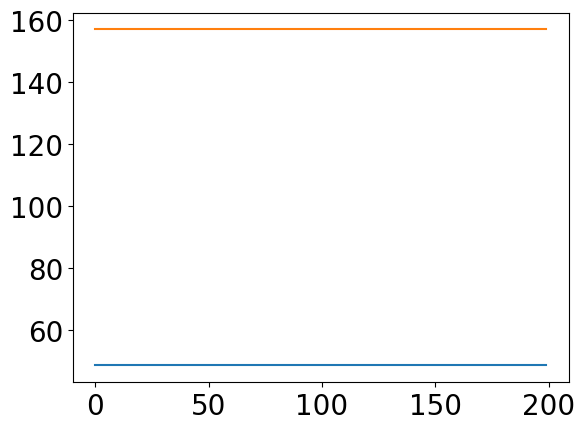

In [12]:

distances = np.ones(200) * 157 + np.random.normal()

def d2r(distance):
    # max_distance = 200
    max_distance = 700
    alpha = 3.0
    peak = 100

    distance = np.clip(distance, 0.0, max_distance)

    reward_raw = np.exp(-alpha * distance / max_distance)
    reward_at_max = np.exp(-alpha)
    reward_norm = (reward_raw - reward_at_max) / (1.0 - reward_at_max)

    return peak * reward_norm

r = d2r(distances)
print(r)
plt.plot(r)
plt.plot(distances)


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

files = glob.glob("demos/*.json")


rewards_list = []

fig, ax = plt.subplots( 1, figsize=(10, 8), sharex=True)
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    time = data["time"]
    rewards = np.array(data["rewards"])
    actions = np.array(data["actions"])
    states = np.array(data["states"])
    rewards_list.append(np.max(rewards))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Reward [m] (subsampled 25%)")
    ax.plot(time, rewards, label="reward", linewidth=LW)
    ax.grid()
    fig.tight_layout()

for r in rewards_list:
    print(r)
print("---")
print(np.max(np.abs(rewards_list)))
plt.show()


In [ ]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt


files = sorted(glob.glob("demos/*.json"))

# ---------- First pass: find best ----------
all_rewards = []
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    all_rewards.append(np.array(data["rewards"]))

best_idx = int(np.argmax([np.max(r) for r in all_rewards]))

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(10, 8))

for i, file in enumerate(files):
    with open(file, "r") as f:
        data = json.load(f)

    rewards = np.array(data["rewards"])
    time = np.array(data["time"])  # <-- use per-file time

    if i == best_idx:
        alpha = 1.0
        lw = LW * 1.5
        label = "best"
        zorder = 3
    else:
        alpha = 0.3
        lw = LW
        label = None
        zorder = 1

    ax.plot(rewards, alpha=alpha, linewidth=lw, zorder=zorder, label=label)

# reference line using first time only (fine)
ref_time = np.array(json.load(open(files[0]))["time"])
# ax.plot(
#     np.full_like(time, ref_reward),
#     linestyle="dashed",
#     color="red",
#     label="ref reward",
# )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [m]")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "datasets/subsample_x4/20260311_140559.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=(10, 8), sharex=True)

ax.set_xlabel("Time [s]")
ax.set_ylabel("states [m] (subsampled 25%)")
ax.plot(time, states[:,0], label="dx", linewidth=LW)
ax.plot(time, states[:,1], label="dy", linewidth=LW)
ax.plot(time, states[:,2], label="dz", linewidth=LW)

ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_x4_states.pdf")
plt.show()


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "datasets/subsample_x4/20260311_140559.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=(10, 8), sharex=True)

ax.set_xlabel("Time [s]")
ax.set_ylabel("actions [m] (subsampled 25%)")
ax.plot(time, actions[:,0], label="dx",linewidth=LW)
ax.plot(time, actions[:,1], label="dy",linewidth=LW)
ax.plot(time, actions[:,2], label="dz",linewidth=LW)

ax.plot(time, actions[:,3], label="droll" , linewidth=LW)
ax.plot(time, actions[:,4], label="dpitch", linewidth=LW)
ax.plot(time, actions[:,5], label="dyaw"  , linewidth=LW)

ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_x4_actions.pdf")
plt.show()


# Dataset

In [4]:

import glob
import json
import numpy as np

demo_data_files = glob.glob("demos/reduced_se3/*.json")

best_reward = -np.inf
best_file = None

for file in demo_data_files:
    with open(file, "r") as f:
        data = json.load(f)

    rewards = np.array(data["rewards"])
    reward = np.max(rewards)
    # reward = np.min(np.abs(rewards))

    if reward > best_reward:
        best_reward = reward
        best_file = file

print(f"Best file: {best_file}")
print(f"Best reward: {best_reward}")


Best file: demos/reduced_se3/20260419_145859.json
Best reward: -0.3303486864615674


In [2]:
import glob
import json
import numpy as np

demo_data_files = glob.glob("datasets/subsample_x3_reduced_se3/*.json")

max_posses = []
min_posses = []
max_rots = []
min_rots = []

for file in demo_data_files:
    with open(file, "r") as f:
        data = json.load(f)

    actions = np.array(data["actions"])

    max_posses.append(np.max(actions[:, :3]))
    min_posses.append(np.min(actions[:, :3]))

    max_rots.append(np.max(actions[:, 3:]))
    min_rots.append(np.min(actions[:, 3:]))

    print(max_rots)
    print(max_posses)

print("max delta pos & ", np.max(max_posses), " & ", np.round(np.max(max_posses), 3), r" \\ \hline")
print("min delta pos & ", np.min(min_posses), " & ", np.round(np.min(min_posses), 3), r" \\ \hline")
print("max delta rot & ", np.max(max_rots)  , " & ", np.round(np.max(max_rots), 3), " / ", np.round(np.rad2deg(np.max(max_rots)),3), r" \\ \hline")
print("min delta rot & ", np.min(min_rots)  , " & ", np.round(np.min(min_rots), 3), " / ", np.round(np.rad2deg(np.min(min_rots)),3), r" \\ \hline")


[np.float64(0.001992857316508889)]
[np.float64(0.0029142857529222965)]
[np.float64(0.001992857316508889), np.float64(0.0043714288622140884)]
[np.float64(0.0029142857529222965), np.float64(0.0026357141323387623)]
[np.float64(0.001992857316508889), np.float64(0.0043714288622140884), np.float64(0.0052071427926421165)]
[np.float64(0.0029142857529222965), np.float64(0.0026357141323387623), np.float64(0.002828571479767561)]
[np.float64(0.001992857316508889), np.float64(0.0043714288622140884), np.float64(0.0052071427926421165), np.float64(0.0030428569298237562)]
[np.float64(0.0029142857529222965), np.float64(0.0026357141323387623), np.float64(0.002828571479767561), np.float64(0.0016071428544819355)]
[np.float64(0.001992857316508889), np.float64(0.0043714288622140884), np.float64(0.0052071427926421165), np.float64(0.0030428569298237562), np.float64(0.005485714413225651)]
[np.float64(0.0029142857529222965), np.float64(0.0026357141323387623), np.float64(0.002828571479767561), np.float64(0.001607

## Dataset Demo Sample Subsample

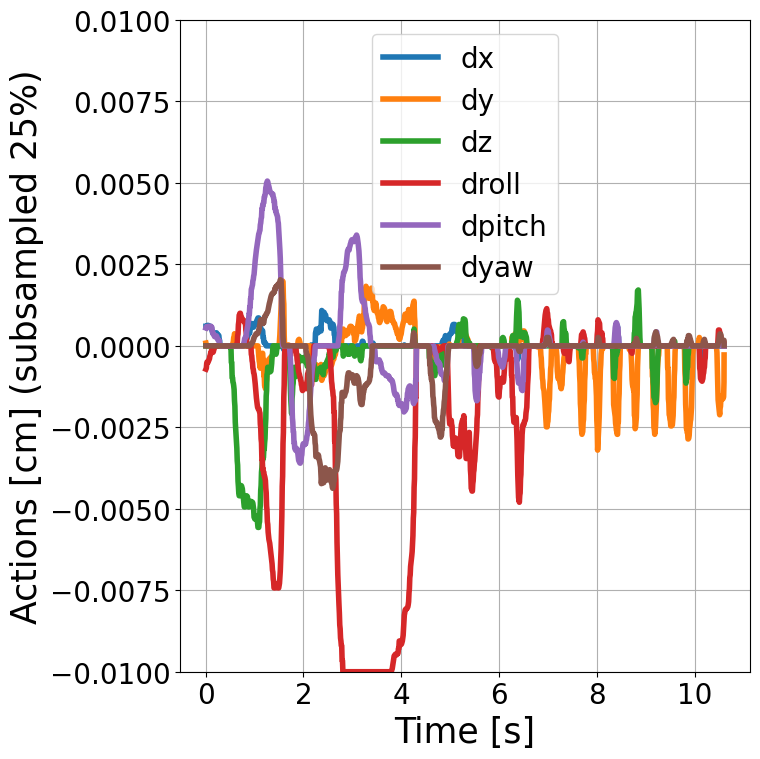

In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "datasets/subsample_x4/20260402_125835.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Actions [cm] (subsampled 25%)")
ax.plot(time, actions[:, 0], label="dx", linewidth=LW)
ax.plot(time, actions[:, 1], label="dy", linewidth=LW)
ax.plot(time, actions[:, 2], label="dz", linewidth=LW)

ax.plot(time, actions[:, 3], label="droll", linewidth=LW)
ax.plot(time, actions[:, 4], label="dpitch", linewidth=LW)
ax.plot(time, actions[:, 5], label="dyaw", linewidth=LW)

ax.grid()

ax.set_ylim([-0.01, 0.01])

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_x4_actions.pdf")
plt.show()


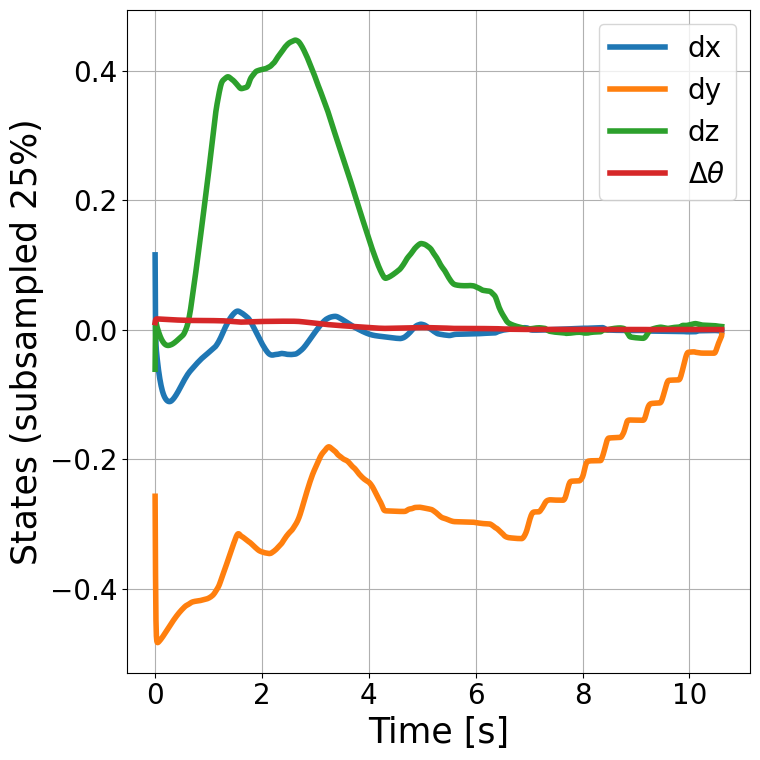

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "datasets/subsample_x4/20260402_125835.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"]) / 100

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Time [s]")
ax.set_ylabel("States (subsampled 25%)")
ax.plot(time, states[:, 0], label="dx", linewidth=LW)
ax.plot(time, states[:, 1], label="dy", linewidth=LW)
ax.plot(time, states[:, 2], label="dz", linewidth=LW)

ax.plot(time, states[:, 3], label=r"$\Delta \theta$", linewidth=LW)
# ax.plot(time, states[:, 4], label="dpitch", linewidth=LW)
# ax.plot(time, states[:, 5], label="dyaw", linewidth=LW)

ax.grid()

# ax.set_ylim([-0.01, 0.01])

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_x4_states.pdf")
plt.show()


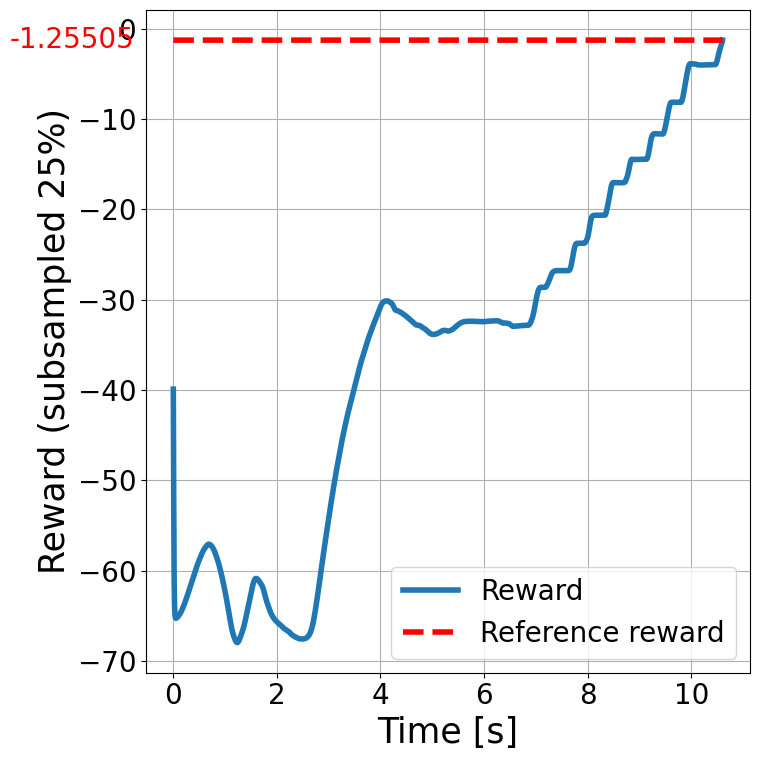

In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "datasets/subsample_x4/20260402_125835.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE,)
abs_ref_rewards = np.ones_like(time) * ABSOLUTE_REWARD_REF

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward (subsampled 25%)")
ax.plot(time, rewards, label="Reward", linewidth=LW)
ax.plot(
    time,
    abs_ref_rewards,
    label="Reference reward",
    linewidth=LW,
    color="red",
    linestyle="--",
)

# mark the y-value on the y-axis
ax.annotate(
    f"{ABSOLUTE_REWARD_REF:.5f}",
    xy=(0, ABSOLUTE_REWARD_REF),
    xycoords=("axes fraction", "data"),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
)
ax.grid()

# ax.set_ylim([-0.002, 0.002])

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_x4_rewards.pdf")
plt.show()


In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "demos/20260311_140559.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=(10, 8), sharex=True)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Actions [m] (not subsampled)")
ax.plot(time, actions[:, 0], label="dx", linewidth=LW)
ax.plot(time, actions[:, 1], label="dy", linewidth=LW)
ax.plot(time, actions[:, 2], label="dz", linewidth=LW)

ax.plot(time, actions[:, 3], label="droll", linewidth=LW)
ax.plot(time, actions[:, 4], label="dpitch", linewidth=LW)
ax.plot(time, actions[:, 5], label="dyaw", linewidth=LW)
ax.set_ylim([-0.002, 0.002])

ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/demo_no_actions_comp.pdf")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'demos/20260311_140559.json'

# IL

## Loss

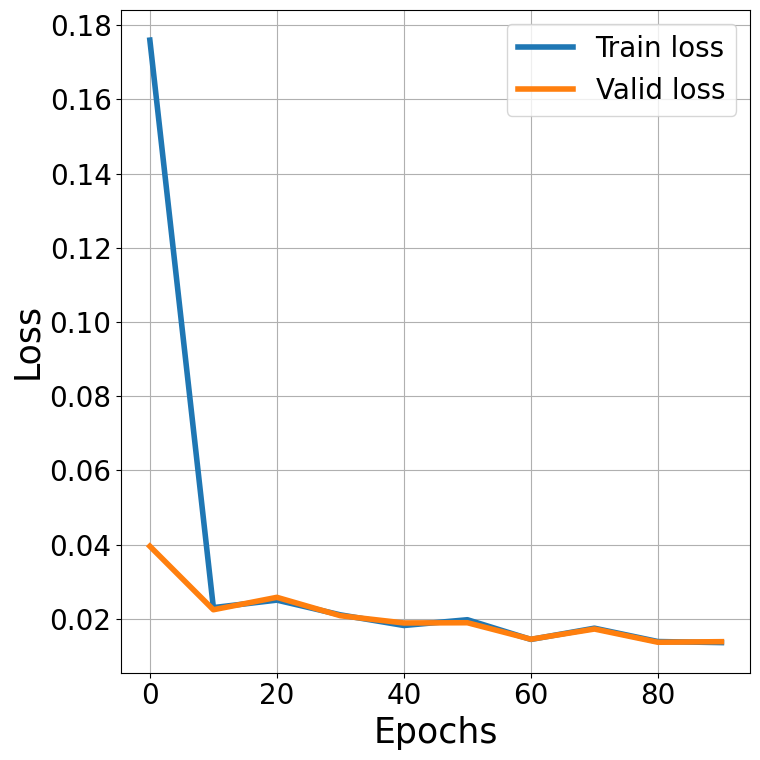

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = (
    ".runs/data_mocap_x4/media/training_history.json"
)
with open(file, "r") as f:
    data = json.load(f)

epochs = np.array(data["epochs"])
train_losses = np.array(data["train_losses"])
val_losses = np.array(data["val_losses"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.plot(epochs, train_losses, label="Train loss", linewidth=LW)
ax.plot(epochs, val_losses, label="Valid loss", linewidth=LW)
ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/il_x4_loss.pdf")
plt.show()


## Rollout

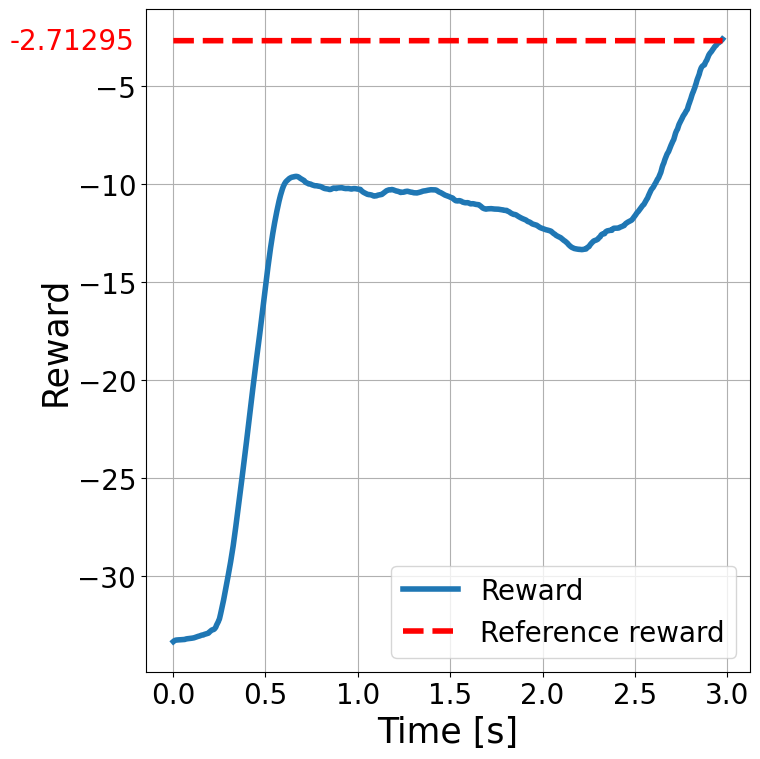

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "data/rollout_dp.json"
with open(file, "r") as f:
    data = json.load(f)

timestep = 0.02
time = data["time"]
rewards = np.array(data["rewards"])
abs_ref_rewards = np.ones_like(time) * ABSOLUTE_REWARD_REF

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward")
ax.plot(time, rewards, label="Reward", linewidth=LW)
# ax.plot(time, ss_ref_rewards, label="ss ref reward", linewidth=LW, color="green", linestyle="--")
ax.plot(
    time,
    abs_ref_rewards,
    label="Reference reward",
    linewidth=LW,
    color="red",
    linestyle="--",
)

# mark the y-value on the y-axis
ax.annotate(
    f"{ABSOLUTE_REWARD_REF:.5f}",
    xy=(0, ABSOLUTE_REWARD_REF),
    xycoords=("axes fraction", "data"),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
)

ax.grid()
ax.legend()
fig.tight_layout()

fig.savefig("figs/il_rollout.pdf")
plt.show()


/tmp/ipykernel_67096/2794861410.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_67096/2794861410.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


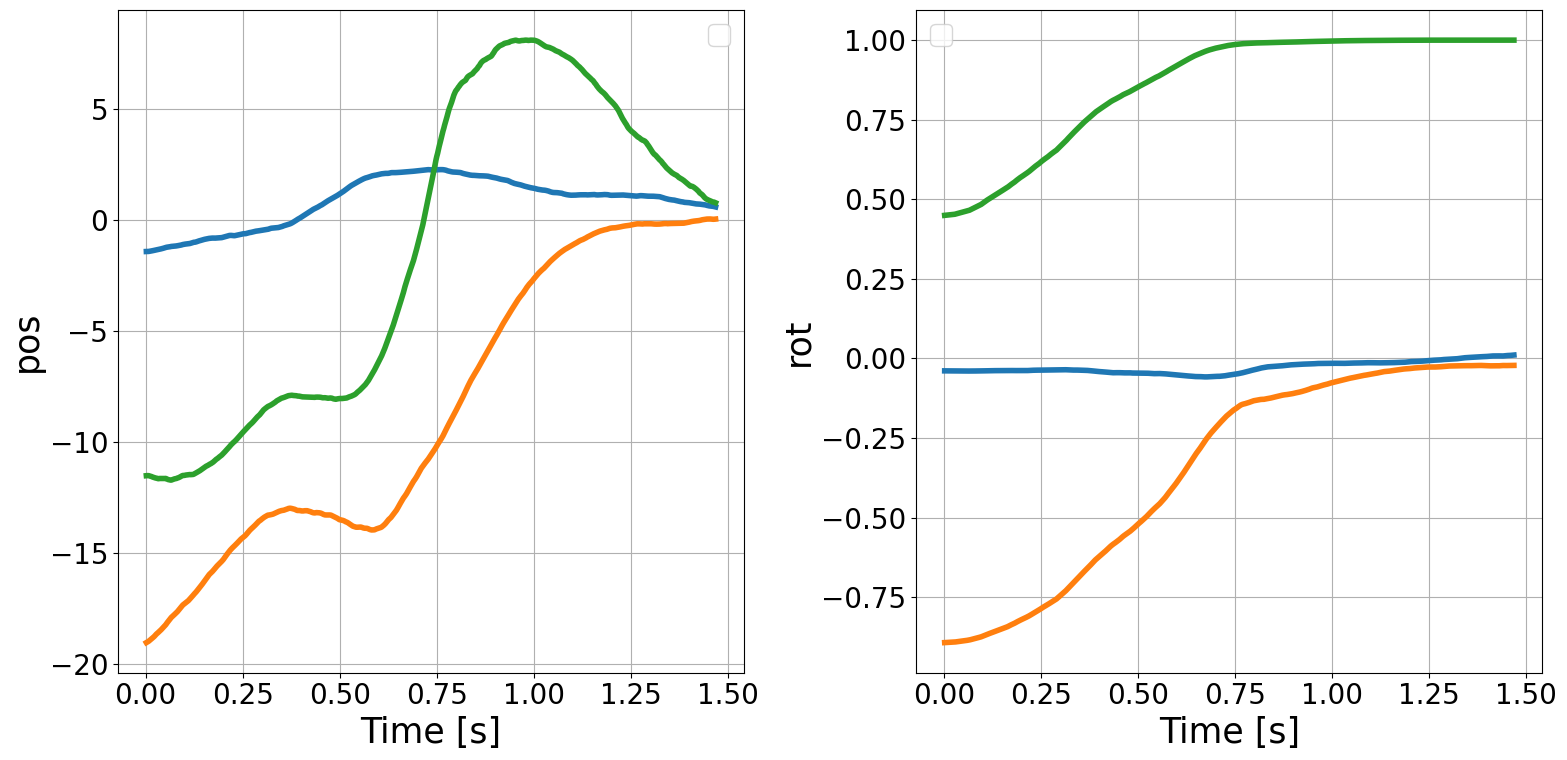

In [24]:

file = "data/rollout_dp_align_z_and_pos.json"
with open(file, "r") as f:
    data = json.load(f)

timestep = 0.02
time = data["time"]
rewards = np.array(data["rewards"])
states = np.array(data["states"])
abs_ref_rewards = np.ones_like(time) * ABSOLUTE_REWARD_REF

fig, ax = plt.subplots(1,2, figsize=(FIG_SIZE[0]*2, FIG_SIZE[1]))

ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("pos")
ax[0].plot(time, states[:,0], linewidth=LW, label="")
ax[0].plot(time, states[:,1], linewidth=LW, label="")
ax[0].plot(time, states[:,2], linewidth=LW, label="")

ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("rot")
ax[1].plot(time, states[:,3], linewidth=LW, label="")
ax[1].plot(time, states[:,4], linewidth=LW, label="")
ax[1].plot(time, states[:,5], linewidth=LW, label="")

fig.tight_layout()
ax[0].grid()
ax[0].legend()
ax[1].grid()
ax[1].legend()

fig.savefig("figs/il_rollout_states.pdf")
plt.show()


## Reward Components

In [ ]:
# plan
# 1) dp rollout position error
# 2) dp rollout orientation error
# 3) demo rollout position error
# 4) demo rollout orientation error

### Reward - Position Error

/tmp/ipykernel_355253/1109045927.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


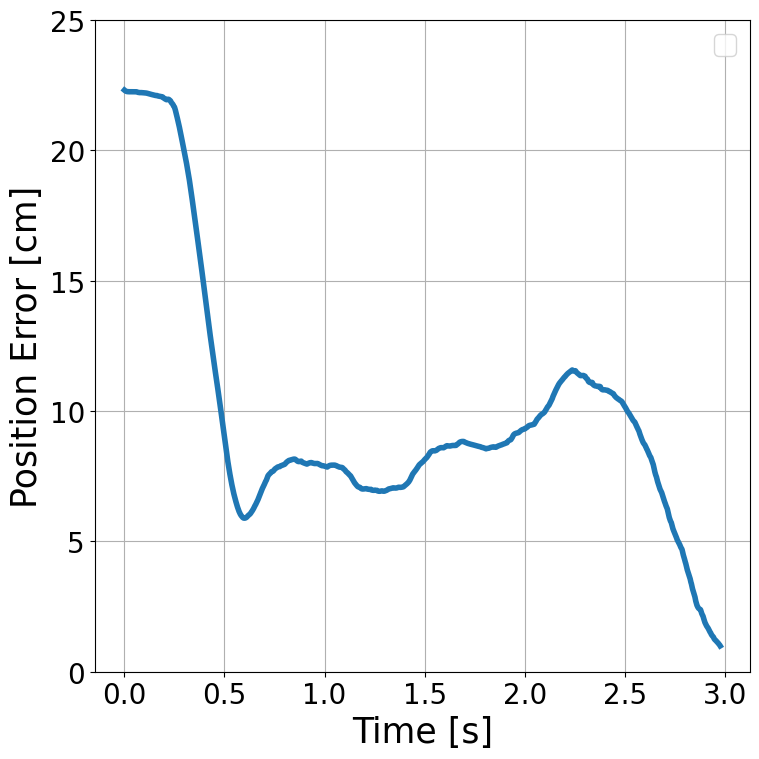

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "data/rollout_dp.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
pos_error = np.array(data["position_errors"])
# ori_error = np.array(data["orientation_errors"])
fig, ax = plt.subplots(1, figsize=FIG_SIZE)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position Error [cm]")
ax.plot(time, pos_error, linewidth=LW)
ax.grid()
ax.legend()
ax.set_ylim([0,25])
fig.tight_layout()
fig.savefig("figs/il_reward_pos_error.pdf")
plt.show()

### Reward - Orientation Error

/tmp/ipykernel_355253/3165449622.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


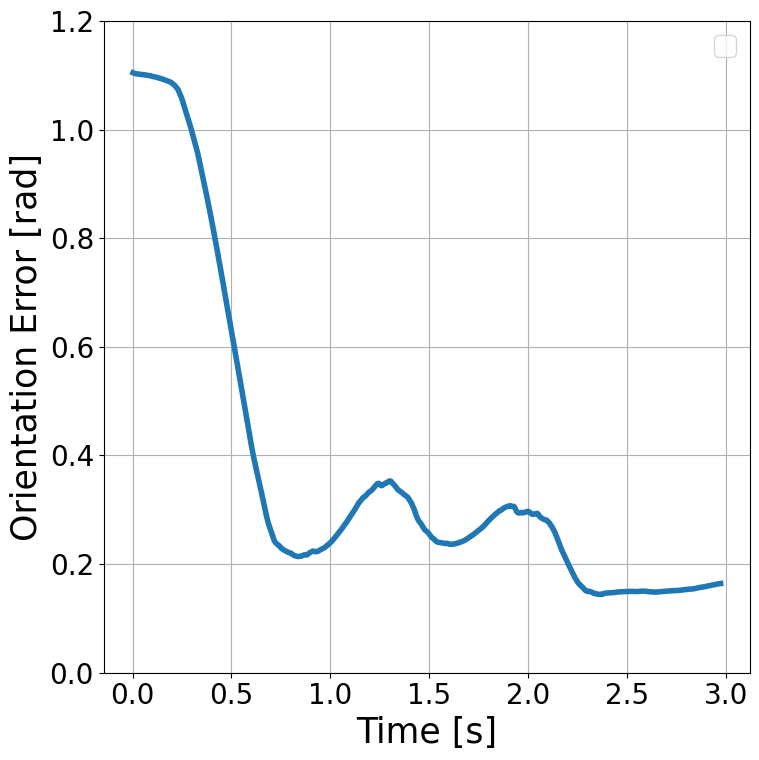

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "data/rollout_dp.json"
with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
# pos_error = np.array(data["position_errors"])
ori_error = np.array(data["orientation_errors"])
fig, ax = plt.subplots(1, figsize=FIG_SIZE)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Orientation Error [rad]")
ax.plot(time, ori_error, linewidth=LW)
ax.grid()
ax.legend()
ax.set_ylim([0,1.2])
fig.tight_layout()
fig.savefig("figs/il_reward_ori_error.pdf")
plt.show()

## IL Actions

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "data/rollout_dp.json"
with open(file, "r") as f:
    data = json.load(f)

timestep = 0.02
print(data["timestep"])
time = data["time"]


rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Actions [m]")
ax.plot(time, actions[:, 0], label="dx", linewidth=LW)
ax.plot(time, actions[:, 1], label="dy", linewidth=LW)
ax.plot(time, actions[:, 2], label="dz", linewidth=LW)

ax.plot(time, actions[:, 3], label="droll", linewidth=LW)
ax.plot(time, actions[:, 4], label="dpitch", linewidth=LW)
ax.plot(time, actions[:, 5], label="dyaw", linewidth=LW)

ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/il_x4_actions.pdf")
plt.show()


## IL States

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

file = "data/rollout_dp.json"
with open(file, "r") as f:
    data = json.load(f)

timestep = 0.02
print(data["timestep"])
time = data["time"]


rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Time [s]")
ax.set_ylabel("States [m]")
ax.plot(time, states[:, 0], label="dx", linewidth=LW)
ax.plot(time, states[:, 1], label="dy", linewidth=LW)
ax.plot(time, states[:, 2], label="dz", linewidth=LW)

ax.grid()

ax.legend()

fig.tight_layout()

fig.savefig("figs/il_x4_states.pdf")
plt.show()


# DRLR

In [6]:
paths = {
    "reward": "data/drlr_reward_v3_2.csv",
    "loss": "data/drlr_loss_v3_2.csv",
    # "rollout": "data/rollout_drlr.json",
}

## Loss

/tmp/ipykernel_1636683/147088186.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


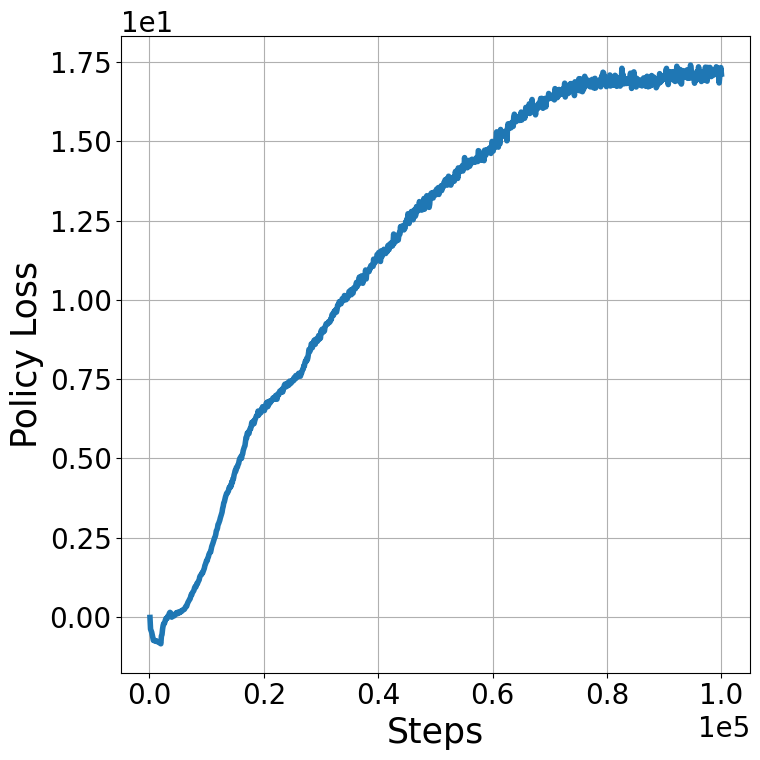

In [7]:
df_100k = pd.read_csv(paths["loss"])

steps = df_100k["global_step"]
loss = df_100k[df_100k.columns[1]]

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.plot(steps, loss, linewidth=LW)
ax.grid()
ax.set_xlabel("Steps")
ax.set_ylabel("Policy Loss")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
fig.tight_layout()
fig.savefig("figs/drlr_loss_2.pdf")

fig.show()


## Reaward

/tmp/ipykernel_1636683/2924519212.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


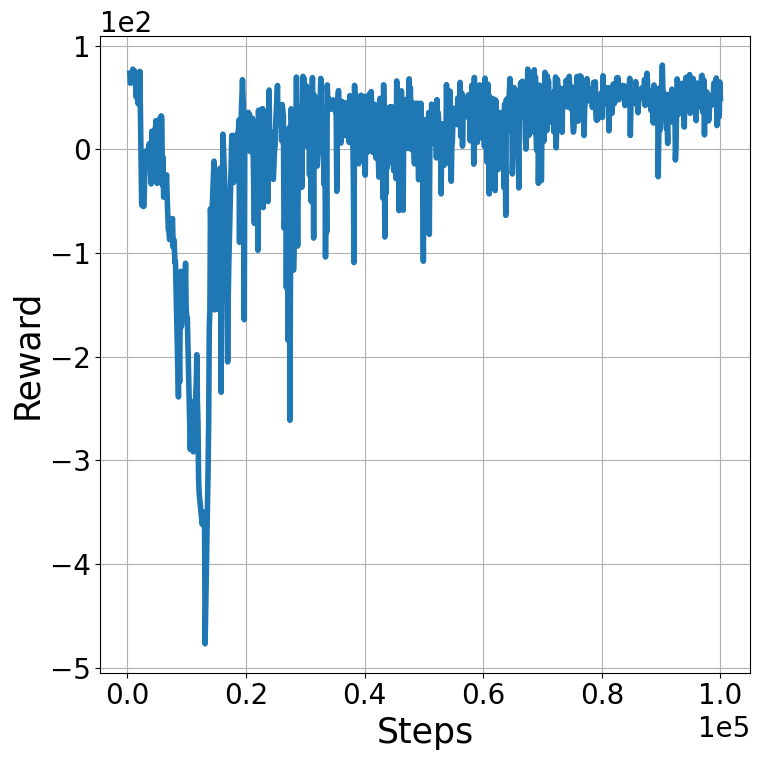

In [9]:
df_100k = pd.read_csv(paths["reward"])

steps = df_100k["global_step"]
loss = df_100k[df_100k.columns[1]]

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.plot(steps, loss, linewidth=LW)
ax.grid()
ax.set_xlabel("Steps")
ax.set_ylabel("Reward")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
fig.tight_layout()
fig.savefig("figs/drlr_reward_2.pdf")

fig.show()


## Rollout

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# file = "datasets/subsample_x4_2/20260311_140559.json"
# file = "datasets/subsample_x4_2/20260311_140559.json"
file = "data/rollout_drlr.json"

with open(file, "r") as f:
    data = json.load(f)

time = data["time"]
rewards = np.array(data["rewards"])
actions = np.array(data["actions"])
states = np.array(data["states"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE, sharex=True)

# ref_reward = -0.009919088333845139
# ref_reward = -0.006618486251682043

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [m]")
ax.plot(time, rewards, label="Reward", linewidth=LW)
ax.plot(
    time,
    np.ones_like(time) * ABSOLUTE_REWARD_REF,
    label="Reference reward",
    linewidth=LW,
    c="red",
    linestyle="dashed",
)

# mark the y-value on the y-axis
ax.annotate(
    f"{ABSOLUTE_REWARD_REF:.5f}",
    xy=(0, ABSOLUTE_REWARD_REF),
    xycoords=("axes fraction", "data"),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
)

ax.grid()
ax.legend()
fig.tight_layout()

fig.savefig("figs/drlr_rollout.pdf")

plt.show()


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

file1 = "data/rollout_drlr.json"
file2 = "data/rollout_dp.json"
file3 = "data/rollout_sac.json"

LW = 4.0

with open(file1, "r") as f:
    data1 = json.load(f)

with open(file2, "r") as f:
    data2 = json.load(f)

with open(file3, "r") as f:
    data3 = json.load(f)

time1 = np.array(data1["time"])
rewards1 = np.array(data1["rewards"])

time3 = np.array(data3["time"])
rewards3 = np.array(data3["rewards"])

time2 = np.array(data2["time"])
rewards2 = np.array(data2["rewards"])
rewards2 = rewards2[rewards2 < -0.02]
time2 = time2[0:len(rewards2)]

fig, ax = plt.subplots(figsize=(10, 8))

# ref_reward = -0.009919088333845139
# ref_reward = -0.006618486251682043*3

# [[-0.00557896  0.42119547  0.13805086]] DRLR
# [[-0.00060028  0.407976    0.168044  ]] DP

# print(ref_reward)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [m]")

ax.plot(time1, rewards1, label="DRLR reward", linewidth=LW)
ax.plot(time2, rewards2, label="IL reward", linewidth=LW)
ax.plot(time3, rewards3, label="RL reward", linewidth=LW)

ax.plot(
    time1,
    np.full_like(time1, ABSOLUTE_REWARD_REF, dtype=float),
    label="Reference reward",
    linewidth=LW,
    color="red",
    linestyle="dashed",
)

ax.grid(True)
ax.legend()
fig.tight_layout()

# fig.savefig("figs/drlr_dp_reward.pdf")
plt.show()


# Rl

In [26]:

paths = {
    "reward": "data/rl_reward.csv",
    "loss": "data/rl_loss.csv",
    # "rollout": "data/rollout_sac_test.json",
}



## Loss

/tmp/ipykernel_56468/419875222.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


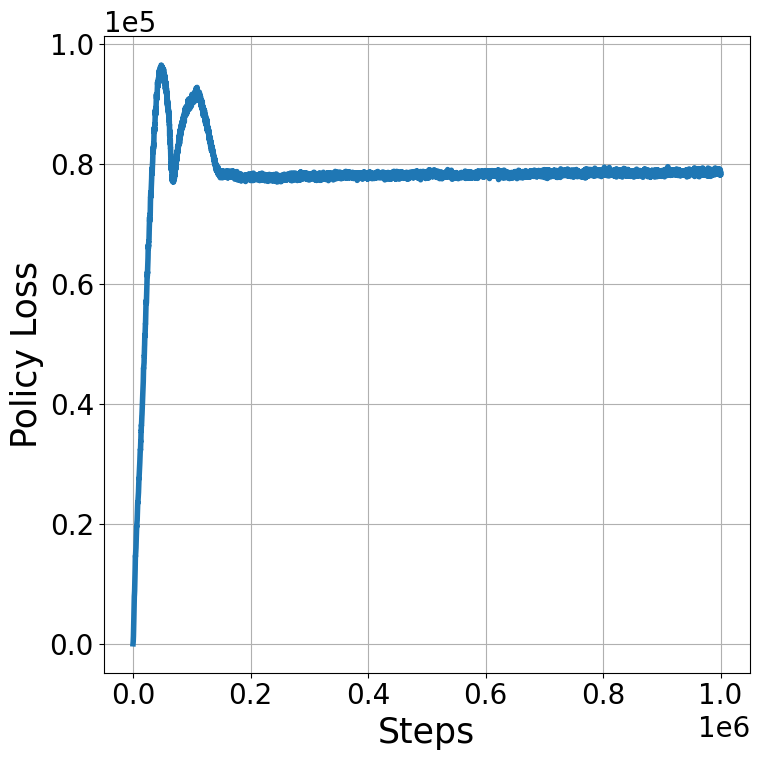

In [27]:

df_100k = pd.read_csv(paths["loss"])

steps = df_100k["global_step"]
loss = df_100k[df_100k.columns[1]]

fig,ax = plt.subplots(1, figsize=FIG_SIZE)

ax.plot(steps, loss, linewidth=LW)
ax.grid()
ax.set_xlabel("Steps")
ax.set_ylabel("Policy Loss")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
fig.tight_layout()
fig.savefig("figs/rl_loss.pdf")

fig.show()

## Reward

/tmp/ipykernel_56468/1565771976.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


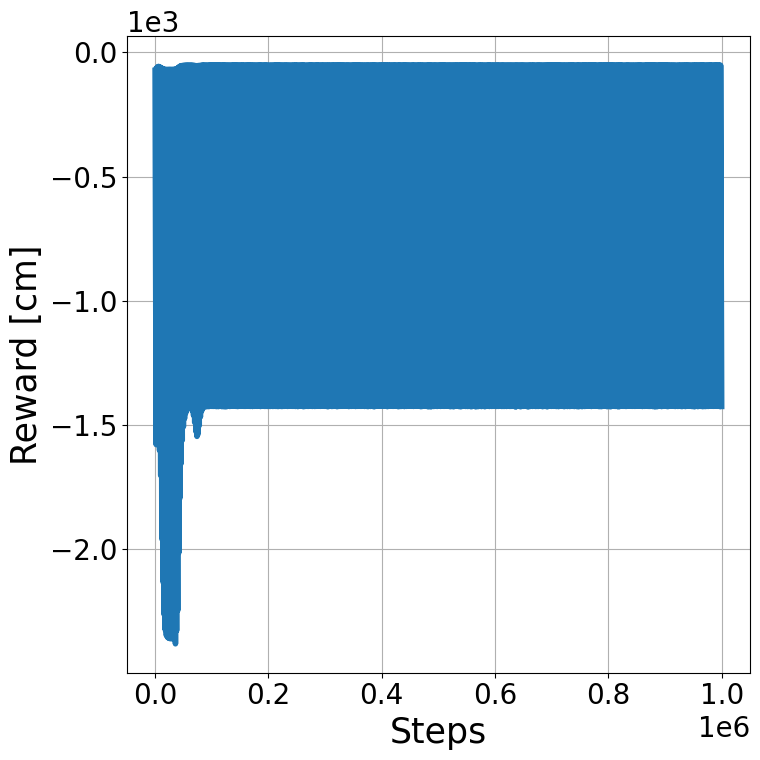

In [ ]:
df_100k = pd.read_csv(paths["reward"])

steps = df_100k["global_step"]
loss = df_100k[df_100k.columns[1]]

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.plot(steps, loss, linewidth=LW)
ax.grid()
ax.set_xlabel("Steps")
ax.set_ylabel("Reward")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
fig.tight_layout()
fig.savefig("figs/rl_reward.pdf")

fig.show()


## Rollout

In [24]:

%matplotlib inline
import matplotlib.pyplot as plt
import json
import matplotlib.pyplot as plt

file = paths["rollout"]

with open(file, "r") as f:
    data = json.load(f)

print(data.keys())

time = data["time"]
rewards = data["rewards"]

fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.plot(time, rewards, linewidth=LW, label="Reward")

ax.annotate(
    f"{ABSOLUTE_REWARD_REF:.5f}",
    xy=(0, ABSOLUTE_REWARD_REF),
    xycoords=("axes fraction", "data"),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
)

ax.axhline(ABSOLUTE_REWARD_REF, linestyle="--", color="red", linewidth=LW, label="Reference reward")

ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [cm]")
ax.legend()
fig.tight_layout()
fig.savefig("figs/rl_rollout.pdf")

plt.show()


KeyError: 'rollout'

# Compare

In [ ]:

rollouts = ["data/rollout_dp.json", "data/rollout_sac.json", "data/rollout_drlr.json"]
losses = [
    "data/sac_policy_loss_100k.csv",
    "data/drlr_loss_100k.csv",
]
rewards = [
    "data/sac_reward_100k.csv",
    "data/drlr_reward_100k.csv",
]


## Loss

In [ ]:
rl_losses_df = pd.read_csv(losses[0])
drlr_losses_df = pd.read_csv(losses[1])

rl_step = rl_losses_df["global_step"]
drlr_step = drlr_losses_df["global_step"]

rl_loss = rl_losses_df[rl_losses_df.columns[1]]
drlr_loss = drlr_losses_df[drlr_losses_df.columns[1]]

abs_ref_rewards = np.ones_like(time) * ABSOLUTE_REWARD_REF


fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.plot(rl_step, rl_loss, label="RL loss", linewidth=LW)
ax.plot(drlr_step, drlr_loss, label="DRLR loss", linewidth=LW)
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

ax.grid()
ax.legend()
fig.tight_layout()

fig.savefig("figs/drlr_rl_loss.pdf")
plt.show()


## Reward

In [ ]:

rl_rewards_df = pd.read_csv(rewards[0])
drlr_rewards_df = pd.read_csv(rewards[1])


rl_step = rl_rewards_df["global_step"]
drlr_step = drlr_rewards_df["global_step"]

rl_reward = rl_rewards_df[rl_rewards_df.columns[1]]
drlr_reward = drlr_rewards_df[drlr_rewards_df.columns[1]]


fig, ax = plt.subplots(1, figsize=FIG_SIZE)

ax.set_xlabel("Steps")
ax.set_ylabel("Reward [cm]")
ax.plot(rl_step, rl_reward, label="RL reward", linewidth=LW)
ax.plot(drlr_step, drlr_reward, label="DRLR reward", linewidth=LW)
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

ax.grid()
ax.legend()
fig.tight_layout()

fig.savefig("figs/drlr_rl_reward.pdf")
plt.show()


## Rollout

In [ ]:

import json
import numpy as np
import matplotlib.pyplot as plt


il_rollout = rollouts[0]
rl_rollout = rollouts[1]
drlr_rollout = rollouts[2]

with open(il_rollout, "r") as f:
    il_data = json.load(f)
with open(rl_rollout, "r") as f:
    rl_data = json.load(f)
with open(drlr_rollout, "r") as f:
    drlr_data = json.load(f)

il_time = il_data["time"]
rl_time = rl_data["time"]
drlr_time = drlr_data["time"]


il_rewards = np.array(il_data["rewards"])
rl_rewards = np.array(rl_data["rewards"])
drlr_rewards = np.array(drlr_data["rewards"])

fig, ax = plt.subplots(1, figsize=FIG_SIZE, sharex=True)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [cm]")
ax.plot(rl_time, rl_rewards, label="RL reward", linewidth=LW)
ax.plot(drlr_time[:1000], drlr_rewards[:1000], label="DRLR reward", linewidth=LW)
ax.plot(il_time, il_rewards, label="IL reward", linewidth=LW)
ax.plot(
    rl_time,
    np.ones_like(rl_time) * ABSOLUTE_REWARD_REF,
    label="Reference reward",
    linewidth=LW,
    c="red",
    linestyle="dashed",
)

# mark the y-value on the y-axis
ax.annotate(
    f"{ABSOLUTE_REWARD_REF:.5f}",
    xy=(0, ABSOLUTE_REWARD_REF),
    xycoords=("axes fraction", "data"),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
)

ax.grid()
ax.legend()
fig.tight_layout()

fig.savefig("figs/drlr_il_rl_rollout.pdf")

plt.show()



# Reward Design

In [3]:
with open(
    "demos/full_se3/20260418_102851.json", "r"
) as f:
    data = json.load(f)

In [6]:


data.keys()

print(data["observations"][0])
print(data["actions"][0])


[[0.9992375911228997, 0.0015601772001996104, -0.0390102849772844, 16.310210151270987], [-0.03554467905050008, 0.4496792199661595, -0.8924825908228257, -5.965709588838506], [0.01614968352946599, 0.8931887622321111, 0.4493918365348527, -18.075846135365943], [0.0, 0.0, 0.0, 1.0]]
[0.0, -0.00025714285714285715, -5e-05, -0.0, 0.0, 0.0]
